## Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

## Configurações

In [2]:
# Diretórios
PROCESSED_DIR = Path("../../data/interim")

# Arquivos de entrada
EXPRESSION_PATH = PROCESSED_DIR / "microplastic_expression.csv"
METADATA_PATH = PROCESSED_DIR / "microplastic_metadata.csv"

# Arquivos de saída
FILTERED_EXPRESSION_PATH = PROCESSED_DIR / "microplastic_expression_filtered.csv"
QC_METRICS_PATH = PROCESSED_DIR / "microplastic_qc_metrics.csv"
LOGCPM_PATH = PROCESSED_DIR / "microplastic_logcpm_filtered.csv"

if not EXPRESSION_PATH.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {EXPRESSION_PATH}")

if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {METADATA_PATH}")

## Carregamento e Validação dos Dados Estruturados

In [3]:
expression_df = pd.read_csv(EXPRESSION_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

print("Matriz de expressão:", expression_df.shape)
print("Metadados:", metadata_df.shape)

display(expression_df.head())
display(metadata_df.head())

Matriz de expressão: (63241, 25)
Metadados: (24, 9)


,gene_id,CTR_1,CTR_2,CTR_3,MA1_1,MA1_2,MA1_3,MD1_1,MD1_2,MD1_3,...,MC1_3,MA100_1,MA100_2,MA100_3,MB100_1,MB100_2,MB100_3,MC100_1,MC100_2,MC100_3
0,ENSG00000000003,357,327,329,276,226,355,276,365,336,...,370,336,285,323,333,233,334,310,358,398
1,ENSG00000000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,770,453,733,605,629,716,655,796,969,...,680,721,700,733,710,703,633,727,974,712
3,ENSG00000000457,27,115,31,26,33,35,42,38,47,...,27,30,31,7,22,40,44,41,68,67
4,ENSG00000000460,37,27,7,4,5,36,3,27,0,...,20,29,3,0,17,9,19,12,21,33


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,sample_id,group,replicate
0,control,NaN,NaN,0.0,True,control,CTR_1,CTR,1
1,control,NaN,NaN,0.0,True,control,CTR_2,CTR,2
2,control,NaN,NaN,0.0,True,control,CTR_3,CTR,3
3,polystyrene,1.0,1000.0,0.1,False,treated,MA1_1,MA1,1
4,polystyrene,1.0,1000.0,0.1,False,treated,MA1_2,MA1,2


In [4]:
# Verifica consistência entre amostras na matriz de expressão e no metadata

sample_columns = [col for col in expression_df.columns if col != "gene_id"]
metadata_samples = metadata_df["sample_id"].tolist()

missing_in_expression = sorted(set(metadata_samples) - set(sample_columns))
missing_in_metadata = sorted(set(sample_columns) - set(metadata_samples))

print("Amostras na expressão:", len(sample_columns))
print("Amostras no metadata:", len(metadata_samples))

if missing_in_expression:
    print("\nPresentes no metadata, ausentes na expressão:")
    print(missing_in_expression)

if missing_in_metadata:
    print("\nPresentes na expressão, ausentes no metadata:")
    print(missing_in_metadata)

if missing_in_expression or missing_in_metadata:
    raise ValueError("Inconsistência entre matriz de expressão e metadados.")

# Reordena a matriz de expressão conforme a ordem do metadata
expression_df = expression_df[["gene_id"] + metadata_samples]

print("\nOrdem final das amostras alinhada ao metadata.")
print(expression_df.columns.tolist()[1:])

Amostras na expressão: 24
Amostras no metadata: 24

Ordem final das amostras alinhada ao metadata.
['CTR_1', 'CTR_2', 'CTR_3', 'MA1_1', 'MA1_2', 'MA1_3', 'MA100_1', 'MA100_2', 'MA100_3', 'MB1_1', 'MB1_2', 'MB1_3', 'MB100_1', 'MB100_2', 'MB100_3', 'MC1_1', 'MC1_2', 'MC1_3', 'MC100_1', 'MC100_2', 'MC100_3', 'MD1_1', 'MD1_2', 'MD1_3']


In [5]:
counts_df = expression_df.set_index("gene_id")

print("Dimensões da matriz de contagens:", counts_df.shape)

# Valores ausentes
n_missing = counts_df.isna().sum().sum()
print("Número total de valores ausentes:", n_missing)

# Tipos
print("\nTipos das colunas:")
print(counts_df.dtypes.value_counts())

# Verifica contagens negativas
has_negative = (counts_df < 0).any().any()
print("\nExistem contagens negativas?", has_negative)

# Verifica se todos os valores parecem inteiros
is_integer_like = np.all(np.equal(np.mod(counts_df.fillna(0).to_numpy(), 1), 0))
print("Todos os valores são inteiros?", is_integer_like)

Dimensões da matriz de contagens: (63241, 24)
Número total de valores ausentes: 0

Tipos das colunas:
int64    24
Name: count, dtype: int64

Existem contagens negativas? False
Todos os valores são inteiros? True


## Calcula Métricas para Controle de Qualidade

In [6]:
# Calcula métricas de qualidade para cada amostra
# - library_size: soma total de contagens por amostra
# - detected_genes_gt0: número de genes com contagem > 0
# - detected_genes_ge10: número de genes com contagem >= 10
# OBS: Quanto usar em detected_genes_ge10?

qc_metrics = pd.DataFrame({
    "sample_id": counts_df.columns,
    "library_size": counts_df.sum(axis=0).values,
    "detected_genes_gt0": (counts_df > 0).sum(axis=0).values,
    "detected_genes_ge10": (counts_df >= 10).sum(axis=0).values,
})

qc_metrics = qc_metrics.merge(metadata_df, on="sample_id", how="left")

display(qc_metrics.sort_values(["group", "replicate"]))

,sample_id,library_size,detected_genes_gt0,detected_genes_ge10,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate
0,CTR_1,13331283,18521,13817,control,NaN,NaN,0.000,True,control,CTR,1
1,CTR_2,12873039,17573,13970,control,NaN,NaN,0.000,True,control,CTR,2
2,CTR_3,12080812,17807,13640,control,NaN,NaN,0.000,True,control,CTR,3
3,MA1_1,11419963,18249,13621,polystyrene,1.0,1000.0,0.100,False,treated,MA1,1
4,MA1_2,11905328,17294,13718,polystyrene,1.0,1000.0,0.100,False,treated,MA1,2
5,MA1_3,14790523,21923,14638,polystyrene,1.0,1000.0,0.100,False,treated,MA1,3
6,MA100_1,13548341,16667,14194,polystyrene,0.1,100.0,0.100,False,treated,MA100,1
7,MA100_2,11437849,16970,13674,polystyrene,0.1,100.0,0.100,False,treated,MA100,2
8,MA100_3,15061137,17205,14628,polystyrene,0.1,100.0,0.100,False,treated,MA100,3
9,MB1_1,9389317,17275,13281,polystyrene,1.0,1000.0,0.010,False,treated,MB1,1


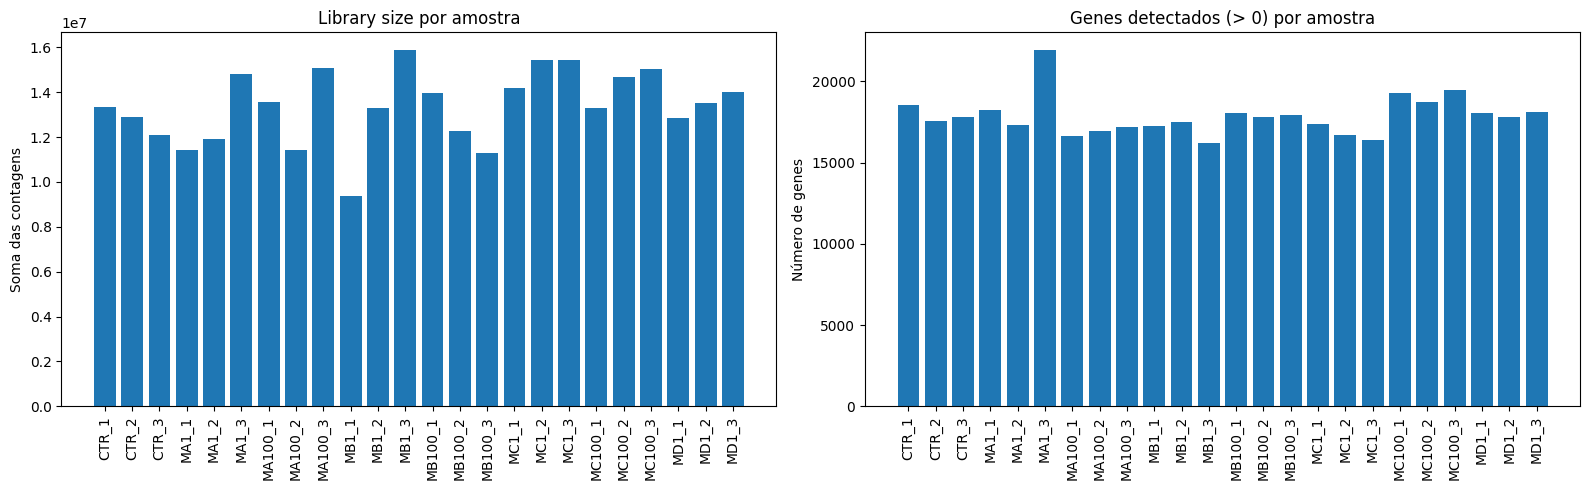

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(qc_metrics["sample_id"], qc_metrics["library_size"])
axes[0].set_title("Library size por amostra")
axes[0].set_ylabel("Soma das contagens")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(qc_metrics["sample_id"], qc_metrics["detected_genes_gt0"])
axes[1].set_title("Genes detectados (> 0) por amostra")
axes[1].set_ylabel("Número de genes")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Funções Auxiliares para CPM (Count-per-Million)

In [8]:
def compute_cpm(counts: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula counts-per-million (CPM) por amostra, normalizando pela library size.
    """
    library_sizes = counts.sum(axis=0)
    cpm = counts.divide(library_sizes, axis=1) * 1_000_000
    return cpm


def compute_logcpm(counts: pd.DataFrame, prior_count: float = 1.0) -> pd.DataFrame:
    """
    Calcula log2(CPM + prior_count), útil para PCA e inspeção visual devido à assimetria de CPM.
    """
    cpm = compute_cpm(counts)
    return np.log2(cpm + prior_count)

## Exploração dos Dados

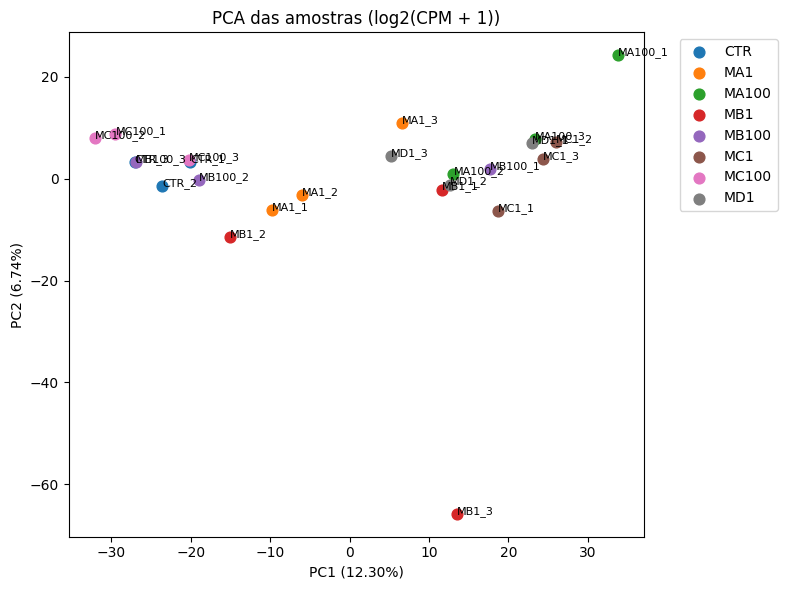

In [9]:
## PCA com logCPM

logcpm_df = compute_logcpm(counts_df)

# PCA espera amostras nas linhas
X = logcpm_df.T.values

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "sample_id": logcpm_df.columns,
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
})

pca_df = pca_df.merge(metadata_df, on="sample_id", how="left")

plt.figure(figsize=(8, 6))

for group, group_df in pca_df.groupby("group"):
    plt.scatter(group_df["PC1"], group_df["PC2"], label=group, s=60)

for _, row in pca_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["sample_id"], fontsize=8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA das amostras (log2(CPM + 1))")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

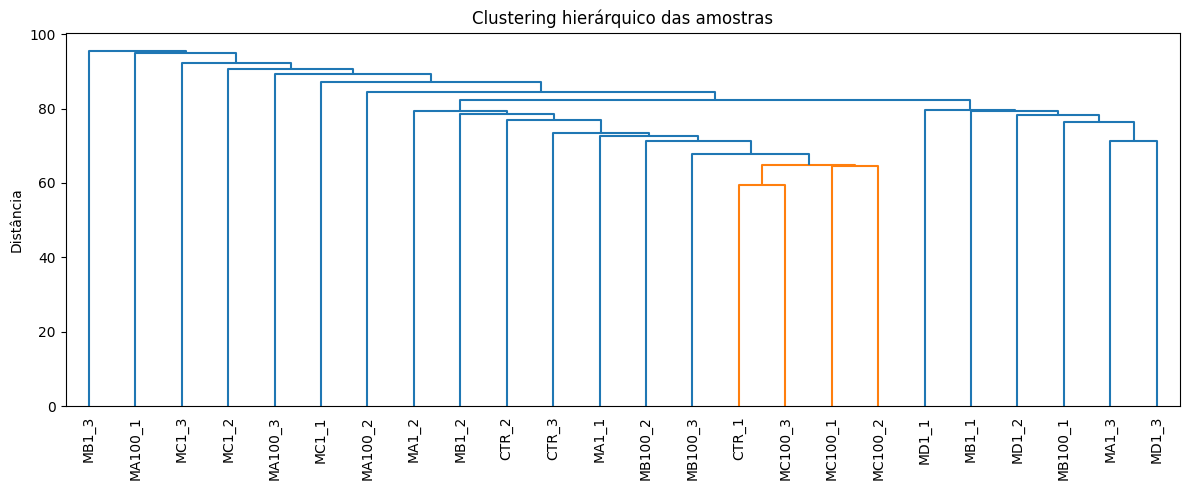

In [10]:
## Clustering hierárquico das amostras

sample_dist = pdist(logcpm_df.T, metric="euclidean")
sample_linkage = linkage(sample_dist, method="average")

plt.figure(figsize=(12, 5))
dendrogram(sample_linkage, labels=logcpm_df.columns.tolist(), leaf_rotation=90)
plt.title("Clustering hierárquico das amostras")
plt.ylabel("Distância")
plt.tight_layout()
plt.show()

## Filtragem de Genes Pouco Expressos

In [11]:
# Critérios de filtragem

MIN_CPM = 1.0
MIN_SAMPLES = 3
MIN_TOTAL_COUNT = 10

cpm_df = compute_cpm(counts_df)

keep_by_cpm = (cpm_df >= MIN_CPM).sum(axis=1) >= MIN_SAMPLES
keep_by_total_count = counts_df.sum(axis=1) >= MIN_TOTAL_COUNT

keep_mask = keep_by_cpm & keep_by_total_count

filtered_counts_df = counts_df.loc[keep_mask].copy()

print("Genes antes da filtragem:", counts_df.shape[0])
print("Genes após a filtragem:", filtered_counts_df.shape[0])
print(f"Genes removidos: {counts_df.shape[0] - filtered_counts_df.shape[0]}")

Genes antes da filtragem: 63241
Genes após a filtragem: 15989
Genes removidos: 47252


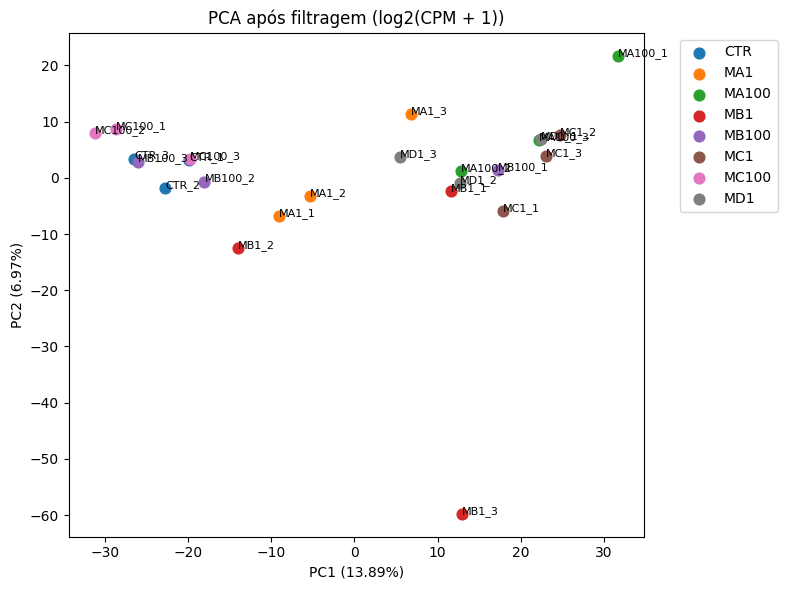

In [12]:
# PCA após filtragem

filtered_logcpm_df = compute_logcpm(filtered_counts_df)

X_filtered = filtered_logcpm_df.T.values

pca_filtered = PCA(n_components=2, random_state=42)
pcs_filtered = pca_filtered.fit_transform(X_filtered)

pca_filtered_df = pd.DataFrame({
    "sample_id": filtered_logcpm_df.columns,
    "PC1": pcs_filtered[:, 0],
    "PC2": pcs_filtered[:, 1],
})

pca_filtered_df = pca_filtered_df.merge(metadata_df, on="sample_id", how="left")

plt.figure(figsize=(8, 6))

for group, group_df in pca_filtered_df.groupby("group"):
    plt.scatter(group_df["PC1"], group_df["PC2"], label=group, s=60)

for _, row in pca_filtered_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["sample_id"], fontsize=8)

plt.xlabel(f"PC1 ({pca_filtered.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_filtered.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA após filtragem (log2(CPM + 1))")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Salvamento dos Artefatos

In [13]:
filtered_expression_df = filtered_counts_df.reset_index()

filtered_expression_df.to_csv(FILTERED_EXPRESSION_PATH, index=False)
qc_metrics.to_csv(QC_METRICS_PATH, index=False)
filtered_logcpm_df.reset_index().to_csv(LOGCPM_PATH, index=False)

print("Arquivos salvos:")
print("-", FILTERED_EXPRESSION_PATH)
print("-", QC_METRICS_PATH)
print("-", LOGCPM_PATH)

Arquivos salvos:
- ../../data/interim/microplastic_expression_filtered.csv
- ../../data/interim/microplastic_qc_metrics.csv
- ../../data/interim/microplastic_logcpm_filtered.csv
